In [2]:
from admmcolinviz import ADMMColin
from matplotlib import pyplot as plt
import numpy as np
import h5py
from admmcolinviz import _transpose_control_triangles
import math

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# import networkx as nx
# import math

# def build_graph(n_x: int, n_y: int):
#     """Graph builder from the provided TV reference."""
#     N = n_x * n_y
#     graph = nx.Graph()
#     graph.add_nodes_from(range(N))

#     for k in range(0, N, 2):
#         if k + 1 < N:
#             graph.add_edge(k, k + 1)
#         if (k + 2) % n_y != 0 and k + 3 < N:
#             graph.add_edge(k, k + 3)
#         if (k // n_y) != 0:
#             nb = k - (n_y - 1)
#             if nb >= 0:
#                 graph.add_edge(k, nb)

#     return graph


# def build_scale(graph: nx.Graph):
#     scale = np.zeros(len(graph.edges()), dtype=float)
#     for k, (u, v) in enumerate(graph.edges()):
#         scale[k] = math.sqrt(2.0) if abs(int(u) - int(v)) == 1 else 1.0
#     return scale


# def compute_tv(control: np.ndarray, graph: nx.Graph, scale: np.ndarray) -> float:
#     diffs = []
#     for (u, v), s in zip(graph.edges(), scale):
#         diffs.append(s * abs(control[u] - control[v]))
#     return float(sum(diffs))


# graph = build_graph(64, 2*64)
# scale = build_scale(graph)
# tv_colin = compute_tv(colin_control, graph, scale)
# tv_oc = compute_tv(oc_control_disc, graph, scale)
# print("OC TV:", tv_oc)
# print("colin TV:", tv_colin)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def _last_value(x):
    arr = np.asarray(x, dtype=float)
    if arr.size == 0:
        raise ValueError("Empty dataset")
    return float(arr.reshape(-1)[-1])


# ----------------------------
# ADMM loader (via ADMMColin)
# ----------------------------
def load_admm_runs(base_dir="run_data_admm_gurobi"):
    rows = []

    for alpha_name in _safe_sorted_dirs(base_dir):
        alpha_path = os.path.join(base_dir, alpha_name)
        alpha = float(alpha_name)

        for fname in sorted(os.listdir(alpha_path)):
            if not fname.endswith(".h5"):
                continue

            dim = int(os.path.splitext(fname)[0])
            try:
                admm = ADMMColin(alpha=alpha, dim=dim, base_dir=base_dir)
                series = admm.trial(0).series

                compliance = _last_value(series.compliance_disc)
                perimeter = _last_value(series.tv_disc)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm",
                        "path": os.path.join(alpha_path, fname),
                    }
                )
            except Exception as exc:
                print(f"Skipped ADMM file {os.path.join(alpha_path, fname)}: {exc}")

    return pd.DataFrame(rows)


# ---------------------------------------
# OC loader (direct root-dataset reading)
# ---------------------------------------
def load_oc_runs(base_dir="oc_method/OC_results"):
    rows = []

    for r_name in _safe_sorted_dirs(base_dir):
        r_path = os.path.join(base_dir, r_name)
        r_val = float(r_name)

        for fname in sorted(os.listdir(r_path)):
            if not fname.endswith(".h5"):
                continue

            h5_path = os.path.join(r_path, fname)
            dim = int(os.path.splitext(fname)[0])

            try:
                with h5py.File(h5_path, "r") as f:
                    #control_disc = f["control_disc"][()]
                    #control_disc_T = _transpose_control_triangles(control_disc, dim)
                    #perimeter = compute_tv(control_disc_T, graph, scale)
                    perimeter = _last_value(f["tv_disc"])
                    compliance = _last_value(f["compliance_disc"])

                rows.append(
                    {
                        "r": r_val,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "oc",
                        "path": h5_path,
                    }
                )
            except Exception as exc:
                print(f"Skipped OC file {h5_path}: {exc}")

    return pd.DataFrame(rows)


admm_df = load_admm_runs(base_dir="admm_colin/run_data_admm_gurobi")
oc_df = load_oc_runs(base_dir="oc_method/OC_results")

print(f"Loaded ADMM points: {len(admm_df)}")
print(f"Loaded OC points: {len(oc_df)}")

if admm_df.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif oc_df.empty:
    print("OC dataframe is empty. Check OC_results.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df["perimeter"].min())
    admm_perimeter_max = float(admm_df["perimeter"].max())

    bin_width = 50.0
    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:blue"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70

    
    df_admm = admm_df.copy()
    df_oc = oc_df.copy()

Loaded ADMM points: 30
Loaded OC points: 160
Using 72 non-overlapping bins of width 50.0 from 151.83 to 3761.55


In [5]:
import numpy as np
import pandas as pd

max_points_per_bin = 6
seed = 0

# Reuse existing bins if available; otherwise rebuild from ADMM perimeter range.
if "bin_starts" not in globals() or "bin_ends" not in globals():
    if "admm_df" not in globals() or admm_df.empty:
        raise ValueError("admm_df is not available. Run the ADMM/OC loading cell first.")

    admm_perimeter_min = float(admm_df["perimeter"].min())
    admm_perimeter_max = float(admm_df["perimeter"].max())
    bin_width = 50.0

    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)


def cap_points_per_bin(df, bin_starts, bin_ends, max_points=6, seed=0):
    if df.empty:
        return df.copy()

    rng = np.random.default_rng(seed)
    capped_parts = []

    for left_edge, right_edge in zip(bin_starts, bin_ends):
        in_bin = df[(df["perimeter"] >= left_edge) & (df["perimeter"] < right_edge)]

        if len(in_bin) > max_points:
            keep_idx = rng.choice(in_bin.index.to_numpy(), size=max_points, replace=False)
            in_bin = in_bin.loc[np.sort(keep_idx)]

        capped_parts.append(in_bin)

    if not capped_parts:
        return df.iloc[0:0].copy()

    capped_df = pd.concat(capped_parts, axis=0)
    return capped_df.reset_index(drop=True)


if "admm_df" not in globals() or "oc_df" not in globals():
    raise ValueError("admm_df or oc_df missing. Run the plotting/data loading cell first.")

admm_df_capped = cap_points_per_bin(admm_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed)
oc_df_capped = cap_points_per_bin(oc_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 1)

# Verification: each bin should have <= max_points_per_bin for both methods.
admm_bin_counts = []
oc_bin_counts = []

for left_edge, right_edge in zip(bin_starts, bin_ends):
    admm_count = int(((admm_df_capped["perimeter"] >= left_edge) & (admm_df_capped["perimeter"] < right_edge)).sum())
    oc_count = int(((oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)).sum())
    admm_bin_counts.append(admm_count)
    oc_bin_counts.append(oc_count)

print("ADMM counts per bin (capped):", admm_bin_counts)
print("OC counts per bin (capped):", oc_bin_counts)
print("ADMM max count:", max(admm_bin_counts) if admm_bin_counts else 0)
print("OC max count:", max(oc_bin_counts) if oc_bin_counts else 0)
print("Total ADMM points after cap:", len(admm_df_capped))
print("Total OC points after cap:", len(oc_df_capped))

ADMM counts per bin (capped): [4, 2, 2, 1, 5, 5, 2, 3, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
OC counts per bin (capped): [6, 6, 6, 6, 6, 6, 6, 6, 2, 1, 4, 4, 6, 1, 3, 3, 1, 1, 1, 0, 0, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ADMM max count: 5
OC max count: 6
Total ADMM points after cap: 29
Total OC points after cap: 81


Using 9 non-overlapping bins of width 50.0 from 151.83 to 648.17


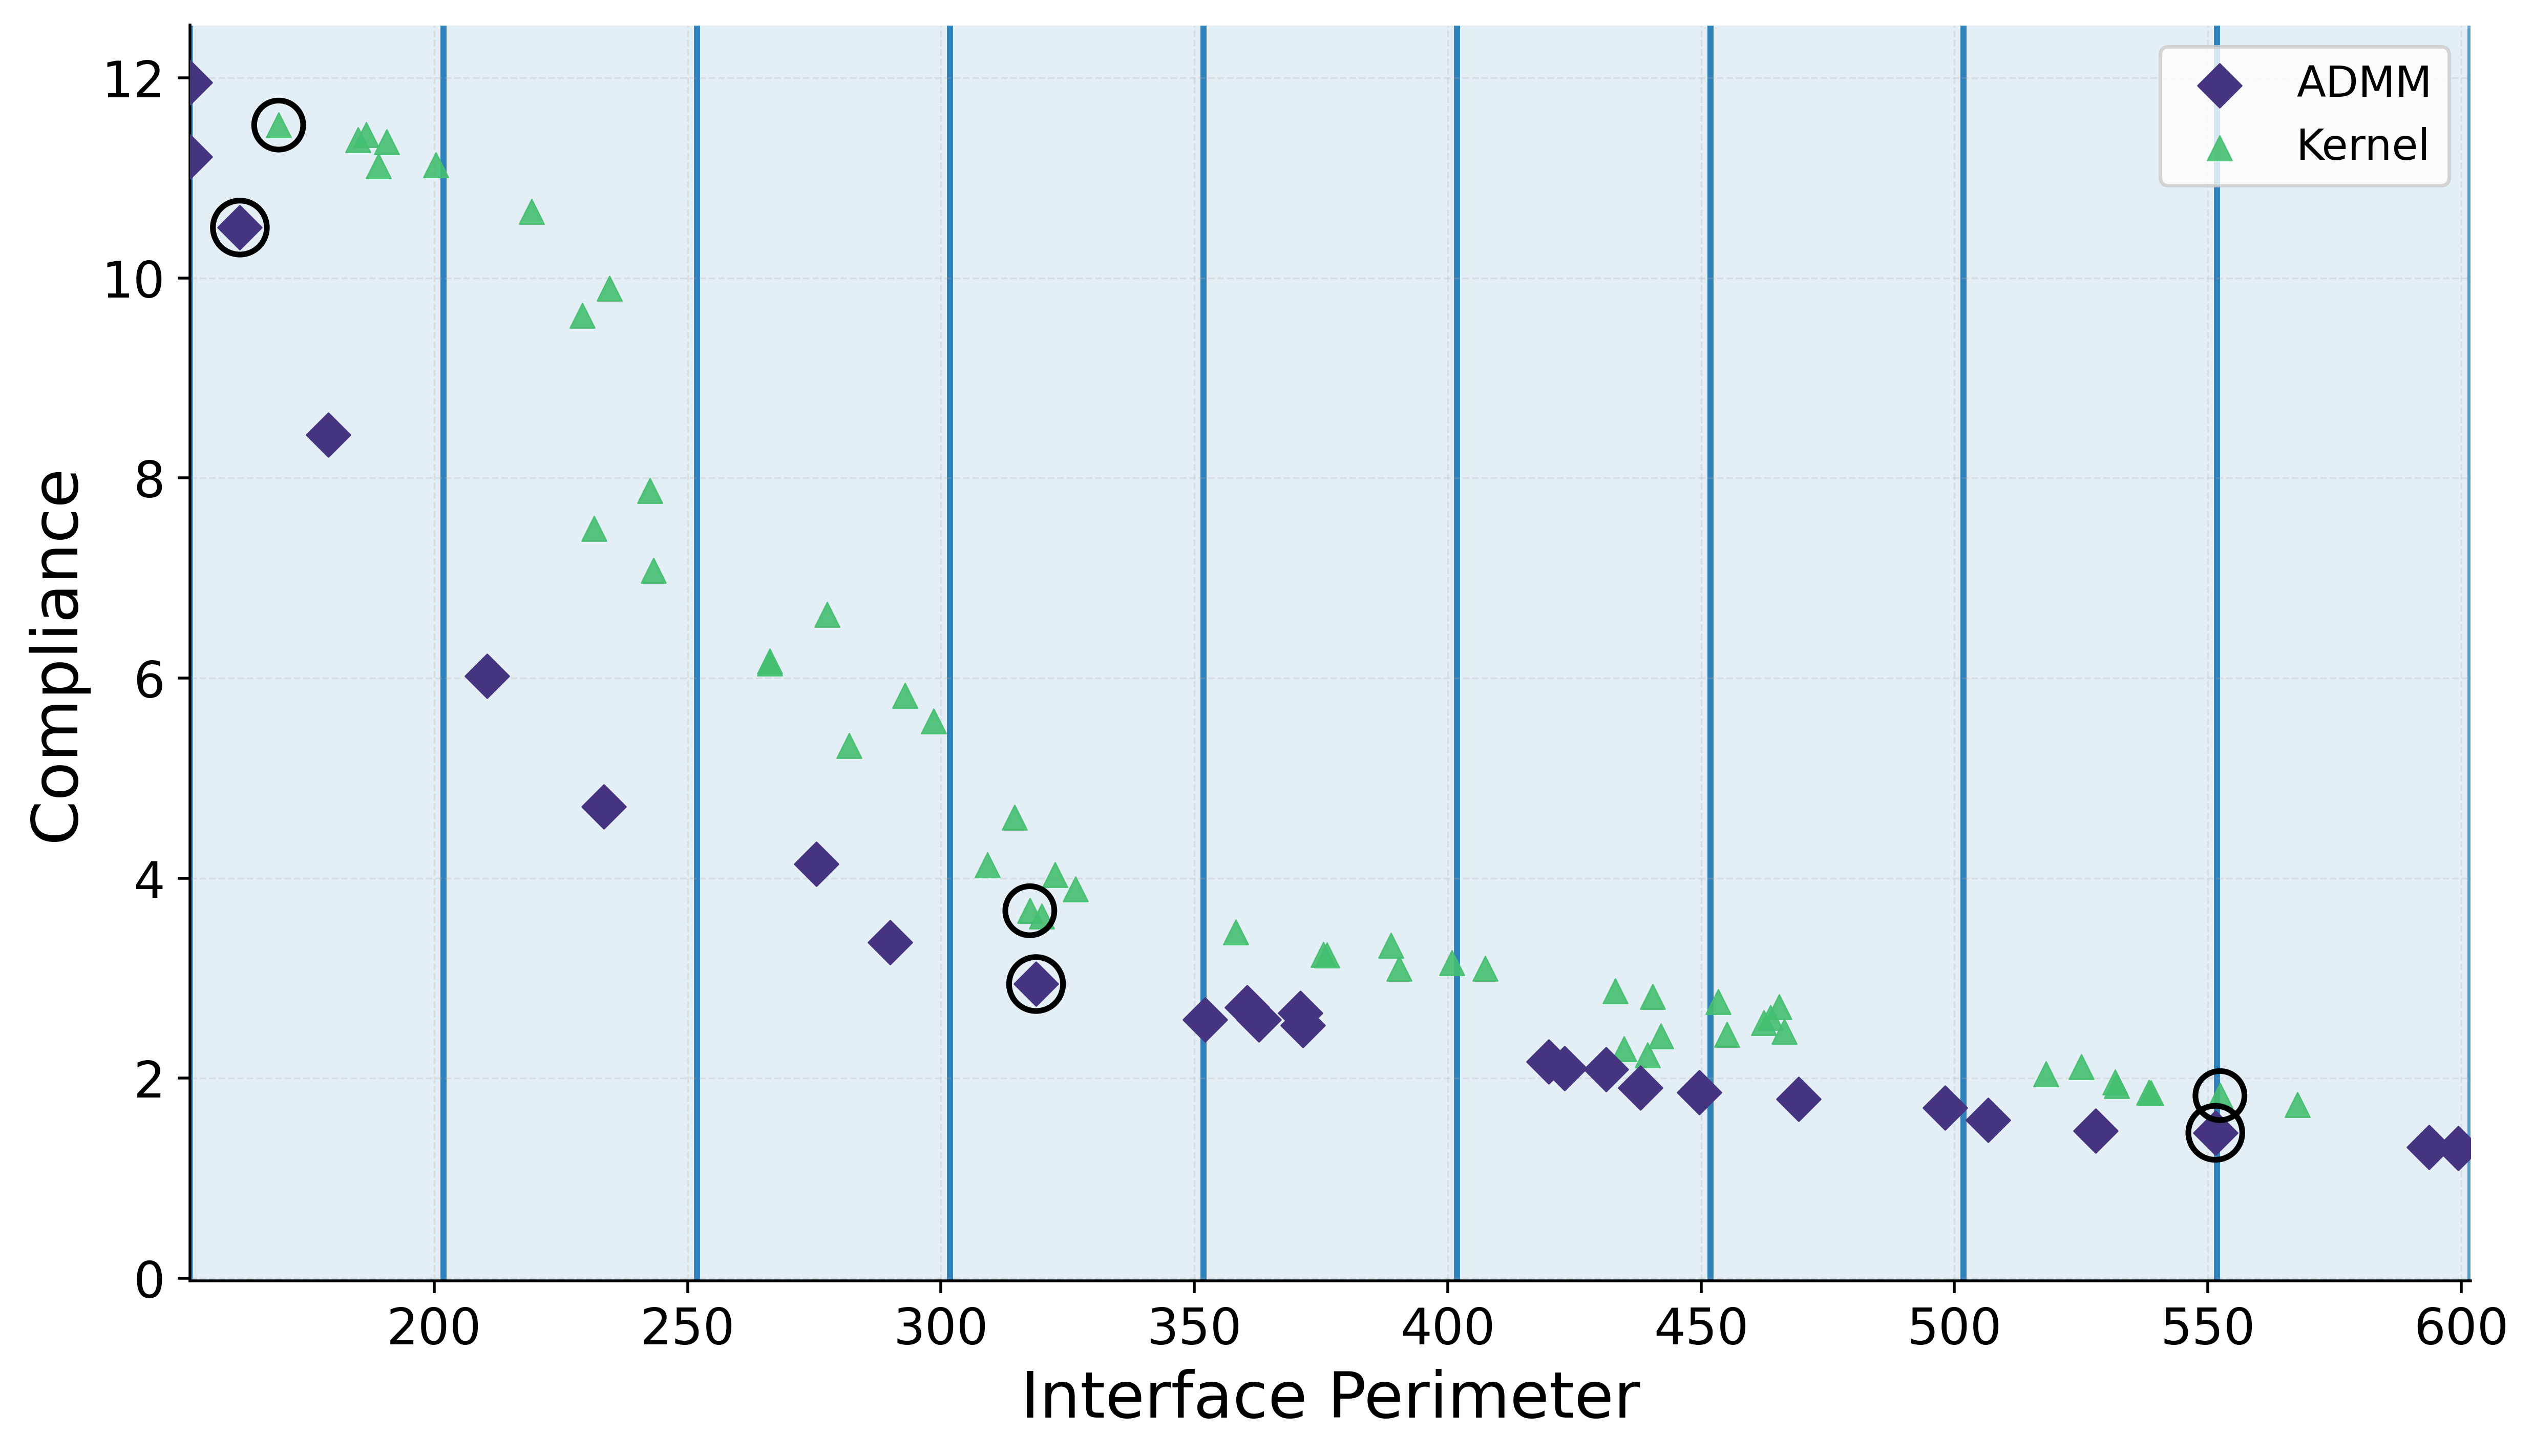

In [6]:
def circle_points(ax, df, mask, x="perimeter", y="compliance",
                  size=220, color="black", label=None, zorder=10):
    ax.scatter(
        df.loc[mask, x],
        df.loc[mask, y],
        marker="o",
        s=size,
        facecolors="none",
        edgecolors=color,
        linewidths=1.6,
        label=label,
        zorder=zorder,
    )

if admm_df_capped.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif oc_df_capped.empty:
    print("OC dataframe is empty. Check OC_results.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df_capped["perimeter"].min())
    admm_perimeter_max = float(admm_df_capped["perimeter"].max())

    bin_width = 50.0
    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:blue"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70
    
    cmap = plt.cm.viridis
    admm_color = cmap(0.15)     # dark purple / blue
    kernel_color = cmap(0.70)   # green-yellow
    highlight_color = "black"   # clean circle color

    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Clearly visible bins: filled rectangles and solid boundaries in the same color.
    for left_edge, right_edge in zip(bin_starts, bin_ends):
        ax.axvspan(left_edge, right_edge, color=BIN_COLOR, alpha=BIN_FILL_ALPHA, zorder=0, linewidth=0)
        ax.axvline(left_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)
        ax.axvline(right_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)

    # ADMM: red diamonds
    sc1 = ax.scatter(
        admm_df_capped["perimeter"],
        admm_df_capped["compliance"],
        marker="D",
        s=75,
        #color="#e74c3c",
        color=admm_color,
        #edgecolors="black",
        linewidth=0.5,
        label="ADMM",
        zorder=4,
    )

    # Kernel/OC: teal markers
    sc2 = ax.scatter(
        oc_df_capped["perimeter"],
        oc_df_capped["compliance"],
        marker="^",
        s=48,
        #color="teal",
        color=kernel_color,
        #edgecolors="black",
        linewidth=0.4,
        alpha=0.9,
        label="Kernel",
        zorder=3,
    )

    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax.legend(frameon=True, fontsize=12)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # condition for marking points of interest
    admm_mask = (((admm_df_capped["perimeter"] > 160) & (admm_df_capped["perimeter"] < 170)) 
                 | ((admm_df_capped["perimeter"] > 315) & (admm_df_capped["perimeter"] < 325))
    | ((admm_df_capped["perimeter"] > 548) & (admm_df_capped["perimeter"] < 552)))
    
    oc_mask = (((oc_df_capped["perimeter"] > 160) & (oc_df_capped["perimeter"] < 170))
               | ((oc_df_capped["perimeter"] > 315) & (oc_df_capped["perimeter"] < 318))
               | ((oc_df_capped["perimeter"] > 548) & (oc_df_capped["perimeter"] < 555)))

    circle_points(
    ax,
    admm_df_capped,
    admm_mask,
    size=230,
    color="black",
    label="Selected ADMM"
    )

    circle_points(
        ax,
        oc_df_capped,
        oc_mask,
        size=190,
        color="black",
        label="Selected Kernel"
    )


    
    # Bin count annotations just above the plot area.
    y_top = max(admm_df_capped["compliance"].max(), oc_df_capped["compliance"].max())
    y_bot = min(admm_df_capped["compliance"].min(), oc_df_capped["compliance"].min())
    y_text = y_top + 0.02 * (y_top - y_bot)

    for c, left_edge, right_edge in zip(centers, bin_starts, bin_ends):
        in_bin = (oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)
        n = int(in_bin.sum())
        # ax.text(c, y_text, str(n), ha="center", va="bottom", fontsize=8, color=BIN_COLOR, alpha=0.85)

    # Neutral labels and ticks (no color coding)
    ax.set_xlabel("Interface Perimeter", fontsize=18)
    ax.set_ylabel("Compliance", fontsize=18)
    ax.set_xlim(admm_perimeter_min, bin_ends[-1])
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.tick_params(axis="both", which="minor", labelsize=12)
    ax.grid(True, alpha=0.25)

    # Use actual scatter handles so legend marker shapes/colors are correct.
    handles = [sc1, sc2]
    labels = [h.get_label() for h in handles]
    # fig.legend(
    #     handles,
    #     labels,
    #     loc="upper center",
    #     bbox_to_anchor=(0.52, 1.05),
    #     ncol=2,
    #     frameon=True,
    #     fontsize=13,
    #     markerscale=1.3,
    # )

    plt.tight_layout(rect=(0, 0.11, 1, 1))
    plt.gcf().set_dpi(500)
    plt.show()

    df_admm = admm_df_capped.copy()
    df_oc = oc_df_capped.copy()

In [7]:
admm_df["mark"] = 0
admm_df["color"] = None
oc_df["mark"] = 0
oc_df["color"] = None

In [8]:
admm_condition = ((admm_df_capped["perimeter"])>160) & ((admm_df_capped["perimeter"])<170)
admm_df_capped.loc[admm_condition, "mark"] = 1
admm_df_capped.loc[admm_condition, "color"] = "black"
alpha = admm_df_capped[admm_condition]["alpha"].values[0]

In [126]:
len(oc_df_capped)

81

In [114]:
oc_condition = ((oc_df_capped["perimeter"])>160) & ((oc_df_capped["perimeter"])<170)
oc_df_capped.loc[oc_condition, "mark"] = 1
oc_df_capped.loc[oc_condition, "color"] = "black"
r = oc_df_capped[oc_condition]["r"].values[0]

In [115]:
admmcolin = ADMMColin(alpha=alpha, dim=64, base_dir="run_data_admm_gurobi")
colin_control = admmcolin.trial(0).iters.control_disc[-1]

In [116]:
admmoc = ADMMColin(alpha=0.019, dim=64, base_dir="run_data_admm_gurobi")
from pathlib import Path
r_value = r
mesh_dim = 64
results_root=Path("OC_results_new")
folder = results_root / f"{float(r):.2f}"
file_path = folder / f"{mesh_dim}.h5"

if not file_path.exists():
    print(f"Run file not found: {file_path}")

with h5py.File(file_path, "r") as h5f:
    oc_control = h5f["control_cont"][()]
    oc_control_disc = h5f["control_disc"][()]
    #oc_control_disc_T = _transpose_control_triangles(oc_control_disc, 64)
    oc_r_attr = float(h5f.attrs.get("r", r_value))
    oc_tv_disc = float(h5f["tv_disc"][()])
    oc_compliance_disc = float(h5f["compliance_disc"][()])

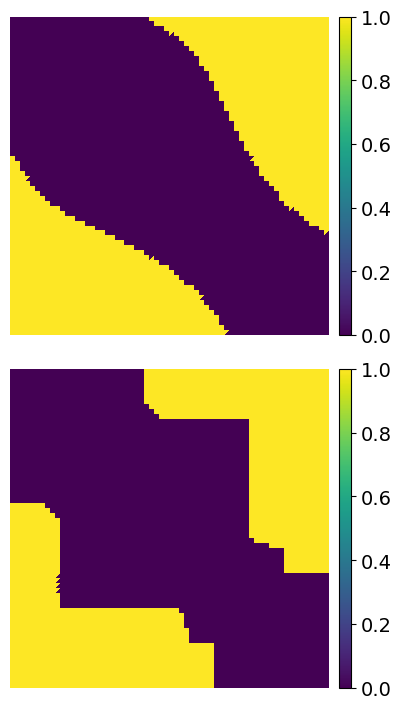

In [124]:
fig, ax = plt.subplots(figsize=(4, 7.2), nrows=2, ncols=1)
admmcolin.plot_control(oc_control_disc, ax=ax[0])
admmcolin.plot_control(colin_control, ax=ax[1])
#plt.gcf().set_dpi(500)
plt.tight_layout()


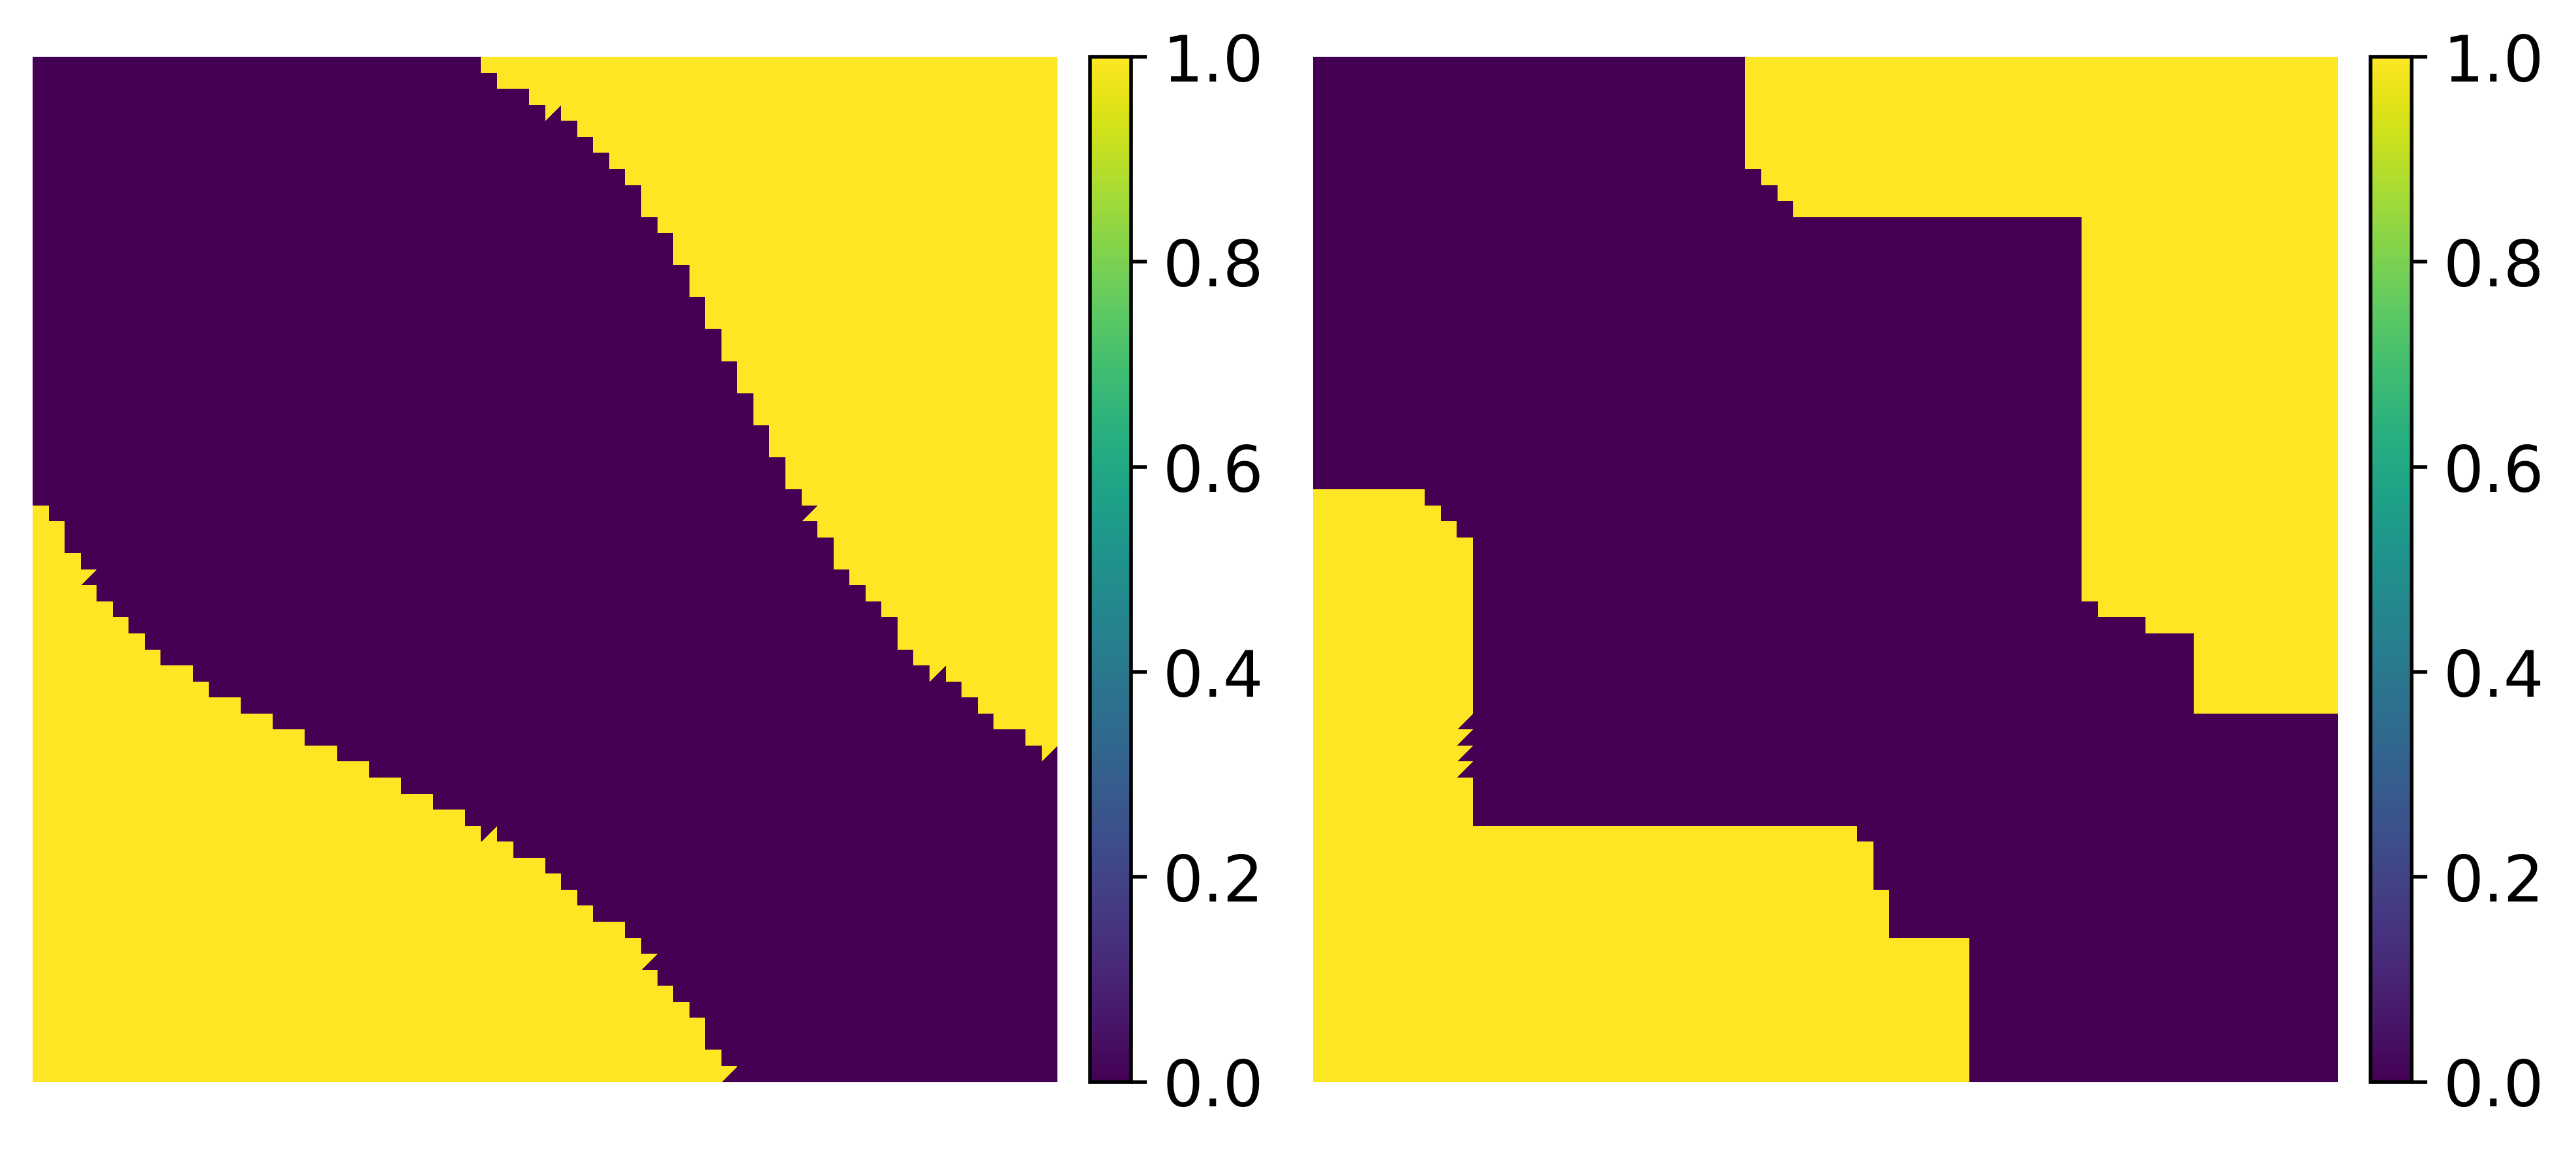

In [121]:
fig, ax = plt.subplots(figsize=(8, 4), nrows=1, ncols=2)
admmcolin.plot_control(oc_control_disc, ax=ax[0])
admmcolin.plot_control(colin_control, ax=ax[1])
plt.gcf().set_dpi(500)
plt.tight_layout()
